# Lab: Comparing Distributions Across Groups

New York City residents can use 311 to report potholes, cave-ins, failed street repairs, and other street conditions. Comparing the daily volume of these requests can help a city describe where reported demand for street-condition services was greatest.

Use the reproducible analysis workflow:

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Learning goals

- use Pandas datetime and string methods to prepare categories;
- use `groupby()`, `.size()`, and `reset_index()` to create daily counts;
- summarize a quantitative feature within groups;
- compare distributions with histograms, box plots, and violin plots;
- interpret center, spread, shape, overlap, and unusual values; and
- distinguish reported request volume from the underlying number of street problems.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The teaching file contains NYC 311 service requests created during 2025 with the complaint type `Street Condition`. Rows assigned to an unspecified borough were excluded. Each row represents one service request, not one unique street problem.

| Feature | Description |
| --- | --- |
| `request_id` | Identifier assigned to the 311 service request |
| `created_date` | Date and time when 311 created the request |
| `borough` | Borough assigned to the request |
| `descriptor` | More specific kind of street condition |

The file was downloaded from NYC Open Data on August 13, 2026. See `data/README.md` for provenance and preparation details.


# Guided analysis

## Step 1: Question

> **How did the daily number of reported street-condition requests differ across New York City's five boroughs in 2025?**


## Step 2: Data

### Import the libraries

Import Pandas, Matplotlib's `pyplot`, and Seaborn using their conventional aliases.


In [18]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read the data

Read `data/nyc_311_street_conditions_2025.csv` into a DataFrame named `requests`. Use `parse_dates=["created_date"]` so Pandas converts the CSV's text timestamps into datetime values while loading the file.


In [19]:
# Write your code here.
requests = pd.read_csv(
    "data/nyc_311_street_conditions_2025.csv",
    parse_dates=["created_date"]
)

### Preview the data

Display the first and last five rows.


In [20]:
# Write your code here.
requests.head()
requests.tail()

,request_id,created_date,borough,descriptor
70193,67353473,2025-12-31 22:26:49,STATEN ISLAND,Pothole
70194,67346881,2025-12-31 22:27:34,STATEN ISLAND,Pothole
70195,67352385,2025-12-31 22:28:43,STATEN ISLAND,Cave-in
70196,67350032,2025-12-31 22:53:19,MANHATTAN,Defective Hardware
70197,67348685,2025-12-31 23:39:14,QUEENS,Pothole


### Inspect the DataFrame

Display its stored data types and missing-value counts.


In [21]:
# Write your code here.
requests.dtypes
requests.isna().sum()

request_id      0
created_date    0
borough         0
descriptor      0
dtype: int64

**Complete the table using the data dictionary and your inspection results.** Classify each feature as categorical, quantitative, or temporal.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `request_id` |  |  |  |
| `created_date` |  |  |  |
| `borough` |  |  |  |
| `descriptor` |  |  |  |


**What does one row represent?**

Your answer: One row represents one NYC 311 street-condition service request created during 2025.


### Predict


**Which borough do you predict will have the greatest typical number of reported street-condition requests per day? What informed your prediction?**

Your answer: I predict Queens will have the greatest typical number of reported street-condition requests per day because it is geographically large and has an extensive street network, which could lead to a larger number of reported street conditions.


## Step 3: Operation


### Make the borough names human-readable

The source stores borough names in all capital letters. **Title case** capitalizes the first letter of each word and writes the remaining letters in lowercase. For example, `STATEN ISLAND` becomes `Staten Island`.

Use `.str.title()` to convert every value in `requests["borough"]` to title case and save the result back into the same feature.


In [22]:
# Write your code here.
requests["borough"] = requests["borough"].str.title()

**What roles do `.str` and `.title()` play in this statement?**

Your answer: .str gives access to Pandas string methods for the values in the borough Series. .title() converts each borough name to title case, such as changing STATEN ISLAND to Staten Island.


### Create a calendar date

Create `requests["date"]` with `requests["created_date"].dt.normalize()`. The `.dt` accessor opens Pandas' datetime tools, and `.normalize()` sets the time in every value to midnight while preserving its calendar date.


In [23]:
# Write your code here.
requests["date"] = requests["created_date"].dt.normalize()

### Count requests for each borough and date

Create a DataFrame named `daily_requests` with this sequence:

1. group `requests` by `date` and `borough`;
2. use `.size()` to count rows in every group; and
3. use `.reset_index(name="request_count")` to return a DataFrame whose count column is named `request_count`.

Display the first five rows.


In [24]:
# Write your code here.
daily_requests = (
    requests
    .groupby(["date", "borough"])
    .size()
    .reset_index(name="request_count")
)

daily_requests.head()

,date,borough,request_count
0,2025-01-01,Bronx,33
1,2025-01-01,Brooklyn,64
2,2025-01-01,Manhattan,14
3,2025-01-01,Queens,70
4,2025-01-01,Staten Island,8


**What does one row of `daily_requests` represent? How is that different from one row of `requests`?**

Your answer: One row of daily_requests represents the total number of street-condition requests recorded in one borough on one calendar date. In contrast, one row of requests represents one individual 311 service request.


**Why did we remove the time before grouping and counting the requests?** As a hint, try repeating the calculation with `created_date` in place of `date` and inspect the result.

Your answer: We removed the time so that all requests made during the same calendar day would be grouped together. If we grouped by the full created_date, requests made at different times would usually be placed in separate groups rather than producing one daily count.


### Set the borough order

Create `borough_order` containing the five borough names in alphabetical order.


In [25]:
# Write your code here.
borough_order = [
    "Bronx",
    "Brooklyn",
    "Manhattan",
    "Queens",
    "Staten Island"
]

### Calculate the mean daily request count

Create `borough_summary` by grouping `daily_requests` by `borough`, selecting `request_count`, calculating the mean, and using `.reindex(borough_order)`.


In [26]:
# Write your code here.
borough_summary = (
    daily_requests
    .groupby("borough")["request_count"]
    .mean()
    .reindex(borough_order)
)

borough_summary

borough
Bronx            19.060274
Brooklyn         50.345205
Manhattan        33.936986
Queens           71.180822
Staten Island    17.800000
Name: request_count, dtype: float64

**Why is comparing only these means incomplete?**

Your answer: Comparing only the means is incomplete because the mean does not show the spread, shape, overlap, or unusual values in each borough's daily request distribution. Two boroughs could have similar means while having very different variability or distributions.


## Step 4: Check


### Check borough-date coverage

Count the number of rows for each borough in `daily_requests`, then use `.reindex(borough_order)`.


In [27]:
# Write your code here.
daily_requests.groupby("borough").size().reindex(borough_order)

borough
Bronx            365
Brooklyn         365
Manhattan        365
Queens           365
Staten Island    365
dtype: int64

**Does every borough have a count for all 365 dates?**

Your answer: Yes. Every borough has 365 rows, so each borough has a daily request count for every date in 2025.


**What would it mean if one or more boroughs had a count of fewer than 365 rows?**

Your answer: It would mean that at least one date was absent for that borough. Because the counts were created only from existing request records, an absent date could mean either that there were zero recorded requests that day or that some data were missing. We would need to investigate before treating the missing date as a zero.


### Check the calculated data

Display missing-value counts for `date`, `borough`, and `request_count`. Then use `.describe()` to summarize `request_count` within each borough and put the boroughs in `borough_order`.


In [28]:
# Write your code here.
daily_requests[["date", "borough", "request_count"]].isna().sum()
daily_requests.groupby("borough")["request_count"].describe().reindex(borough_order)

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,365.0,19.060274,9.238398,1.0,12.0,18.0,25.0,48.0
Brooklyn,365.0,50.345205,21.132529,6.0,33.0,51.0,65.0,113.0
Manhattan,365.0,33.936986,14.683432,2.0,23.0,33.0,43.0,91.0
Queens,365.0,71.180822,30.362103,11.0,47.0,70.0,89.0,215.0
Staten Island,365.0,17.800000,10.095206,1.0,10.0,17.0,24.0,66.0


**Are any calculated values missing or impossible?**

Your answer: No. There are no missing calculated values, and all request counts are positive whole numbers, which is reasonable for daily counts.


**Would a zero necessarily be impossible in another 311 dataset?**

Your answer: No. A zero could be valid if no requests of that type were recorded for a borough on a particular day. In this dataset, however, every borough had at least one request on every day.


## Step 5: Evidence


### Create overlapping histograms

Use `sns.histplot()` with:

- `data=daily_requests`;
- `x="request_count"`;
- `hue="borough"` and `hue_order=borough_order`;
- `element="step"`;
- layered histograms;
- `alpha=0.45`; and
- the `"deep"` palette.

Capitalize the legend title and add a question-focused title and descriptive axis labels. Label the y-axis `Number of days`.


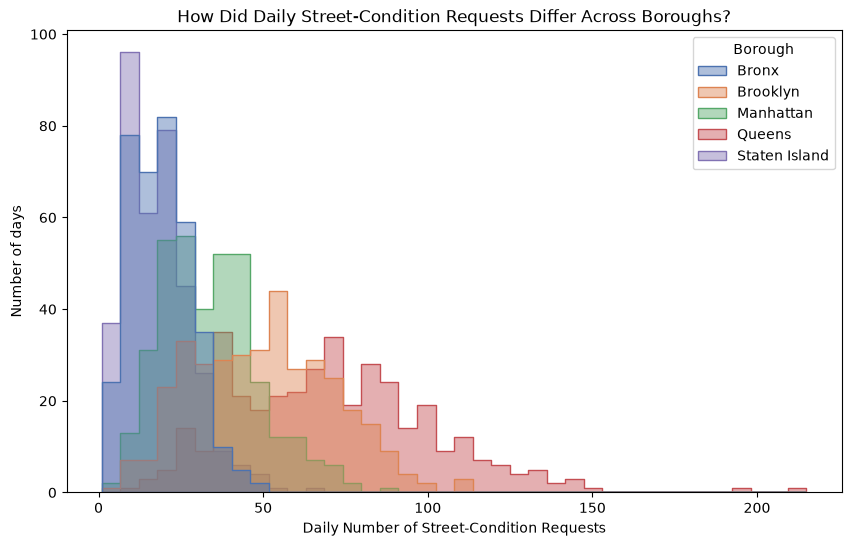

In [29]:
# Write your code here.
plt.figure(figsize=(10, 6))

sns.histplot(
    data=daily_requests,
    x="request_count",
    hue="borough",
    hue_order=borough_order,
    element="step",
    multiple="layer",
    alpha=0.45,
    palette="deep"
)

plt.title("How Did Daily Street-Condition Requests Differ Across Boroughs?")
plt.xlabel("Daily Number of Street-Condition Requests")
plt.ylabel("Number of days")

sns.move_legend(plt.gca(), "upper right", title="Borough")

plt.show()

**What does the histogram reveal, and what makes the boroughs easy or difficult to compare?**

Your answer: The histogram shows that Queens generally had the highest daily request counts, followed by Brooklyn and Manhattan, while the Bronx and Staten Island generally had lower counts. It also shows differences in spread and distribution shape. However, because the five histograms overlap, some portions are difficult to compare precisely.


### Create a box plot

Put `request_count` on the x-axis and `borough` on the y-axis. Use `borough_order`, the named color `"mediumseagreen"`, and descriptive labels.


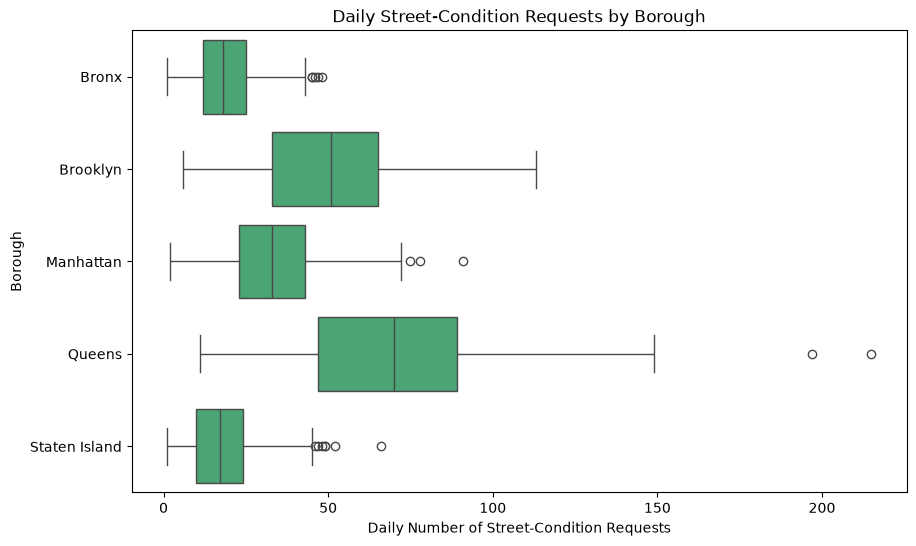

In [30]:
# Write your code here.
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumseagreen"
)

plt.title("Daily Street-Condition Requests by Borough")
plt.xlabel("Daily Number of Street-Condition Requests")
plt.ylabel("Borough")

plt.show()

**What differences among boroughs are easier to see in the box plot than in the histogram?**

Your answer: The box plot makes the differences in medians, spread, and unusual high values easier to compare. Queens has the highest median at about 70 requests per day and the largest overall spread. Brooklyn and Manhattan have lower medians, while the Bronx and Staten Island have the lowest typical daily counts.


### Create a violin plot

Use the same x feature, y feature, and order. Change only the plot color to `"mediumpurple"` in addition to the required data mappings and order.


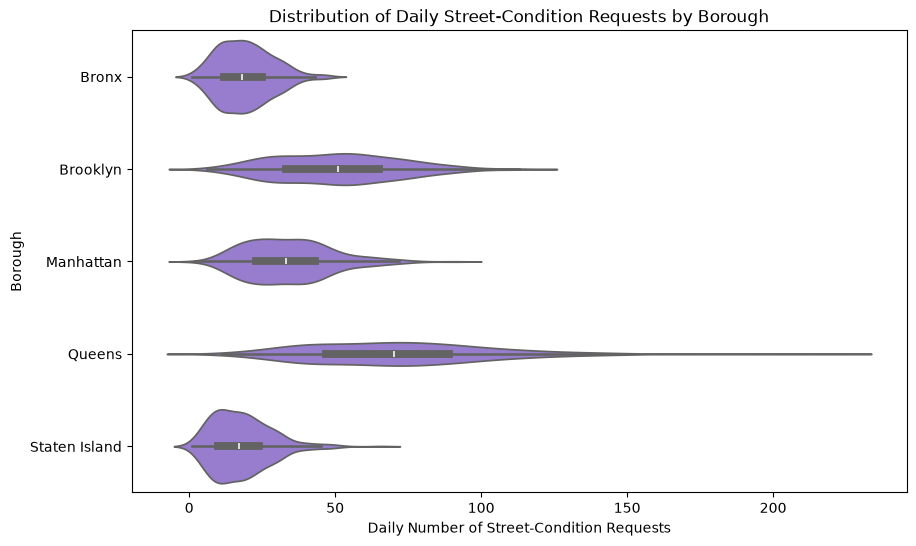

In [31]:
# Write your code here.
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=daily_requests,
    x="request_count",
    y="borough",
    order=borough_order,
    color="mediumpurple"
)

plt.title("Distribution of Daily Street-Condition Requests by Borough")
plt.xlabel("Daily Number of Street-Condition Requests")
plt.ylabel("Borough")

plt.show()

**What does the violin plot add to the comparison?**

Your answer: The violin plot adds information about the shape and density of each distribution. The wider portions show where daily request counts were more common, making it easier to see concentrations, skewness, and differences in distribution shape that are not as visible in the box plot.


**Which of the three figures most clearly compares daily request counts among boroughs? Explain your choice.**

Your answer: The box plot most clearly compares the boroughs because it shows the median, spread, and unusual values without the visual overlap of the histogram. It makes the differences in typical daily request volume especially easy to see.


## Step 6: Conclusion


**What conclusion about borough differences is supported by the 2025 data?**

Your answer: Daily reported street-condition request volume differed substantially across boroughs in 2025. Queens had the greatest typical volume, with a median of 70 requests per day and a mean of about 71.18. Brooklyn was next with a median of 51, followed by Manhattan at 33. The Bronx and Staten Island had the lowest typical daily volumes, with medians of 18 and 17 requests respectively.


## Step 7: Limitation


**Why do these request counts not directly measure the number of street problems or borough performance?**

Your answer: The request counts measure reported 311 requests, not the actual number of street problems. Multiple requests could refer to the same problem, and some street problems may never be reported. Differences in population, street mileage, reporting behavior, awareness of 311, and other factors could also influence the number of requests, so these counts should not be interpreted directly as borough performance.


# Your own analysis

Develop a new research question using the 311 data. Your question must compare a **quantitative feature across categorical groups**. You will probably need to calculate the quantitative feature from the original request records.

Possible grouping features include `descriptor`, month, or day of the week. You may use another meaningful categorical feature that you can create and explain.


## Step 1: Question


**Write a research question that compares a quantitative feature across categorical groups.**

Your answer: How did the daily number of reported street-condition requests differ across months in 2025?


## Step 2: Data


**Which original features will you use, and what will each row of your calculated DataFrame represent?**

Your answer: I will use created_date to determine both the calendar date and month of each request. Each row of the calculated DataFrame will represent the total number of street-condition requests recorded on one day, along with the month containing that day.


## Step 3: Operation

Prepare the grouping feature, calculate the quantitative feature, and save the resulting DataFrame with a meaningful name.


In [32]:
# Write your code here.
requests["month"] = requests["created_date"].dt.month_name()

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

daily_by_month = (
    requests
    .groupby(["date", "month"])
    .size()
    .reset_index(name="request_count")
)

daily_by_month.head()

,date,month,request_count
0,2025-01-01,January,189
1,2025-01-02,January,240
2,2025-01-03,January,136
3,2025-01-04,January,110
4,2025-01-05,January,155


**Briefly explain how your code produced the quantitative feature and comparison groups.**

Your answer: The code extracted the month name from each request's creation date. It then grouped requests by calendar date and month and counted the number of request records in each group. The resulting request_count is the quantitative feature, and the months are the categorical comparison groups.


## Step 4: Check

Check the calculated data for missing or impossible values, confirm that the intended groups are present, and use an appropriate numerical summary to inspect the distributions.


In [33]:
# Write your code here.
daily_by_month.isna().sum()
daily_by_month["month"].nunique()
daily_by_month.groupby("month").size().reindex(month_order)
daily_by_month.groupby("month")["request_count"].describe().reindex(month_order)

,count,mean,std,min,25%,50%,75%,max
month,,,,,,,,
January,31.0,176.322581,64.229478,57.0,126.00,187.0,229.00,289.0
February,28.0,200.535714,71.319044,95.0,149.00,189.0,258.00,362.0
March,31.0,226.258065,68.748318,118.0,151.00,239.0,279.00,328.0
April,30.0,221.666667,58.439083,114.0,171.25,245.0,272.75,289.0
May,31.0,239.903226,81.063907,124.0,164.50,257.0,301.00,426.0
June,30.0,241.066667,76.516815,109.0,161.25,266.5,303.25,348.0
July,31.0,197.290323,66.355203,63.0,136.00,213.0,244.50,301.0
August,31.0,180.161290,52.436690,72.0,136.50,201.0,213.50,294.0
September,30.0,179.900000,59.527073,81.0,114.50,193.0,223.50,266.0


**What did your checks establish?**

Your answer: The checks established that there were no missing values in the calculated data, all 12 months were present, and every calendar day of 2025 was represented. The daily request counts were also positive and within plausible ranges.


## Step 5: Evidence

Create a histogram, box plot, or violin plot that directly addresses your question. Include a clear title and descriptive axis labels.


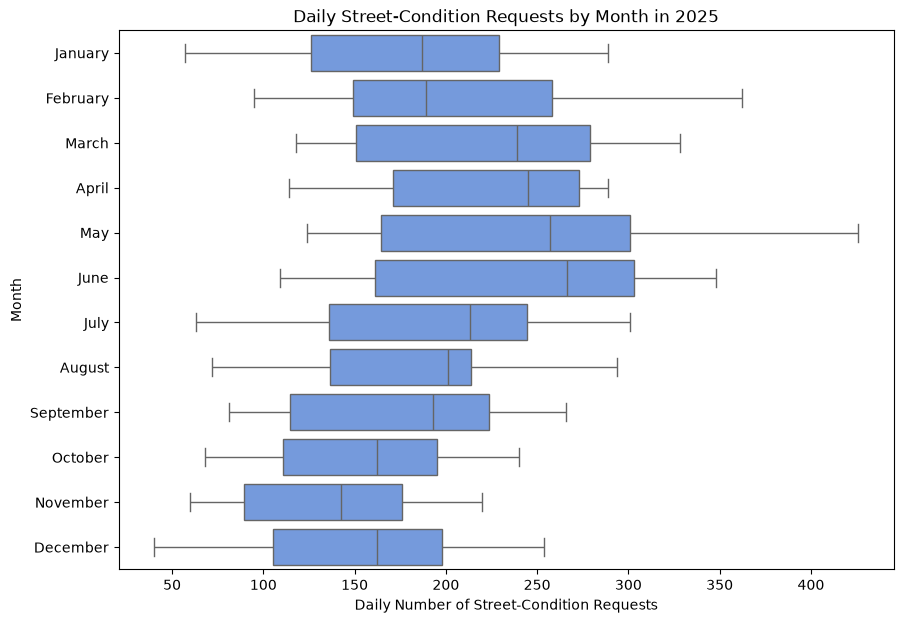

In [34]:
# Write your code here.
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=daily_by_month,
    x="request_count",
    y="month",
    order=month_order,
    color="cornflowerblue"
)

plt.title("Daily Street-Condition Requests by Month in 2025")
plt.xlabel("Daily Number of Street-Condition Requests")
plt.ylabel("Month")

plt.show()

**What pattern in the figure provides the strongest evidence for your answer?**

Your answer: The strongest pattern is that the distributions for late spring and early summer are shifted toward higher daily request counts. June has the highest median at about 266.5 requests per day, while November has the lowest median at about 142.5. May also shows several high daily request counts and the largest observed daily value.


## Step 6: Conclusion


**State one conclusion that directly answers your research question.**

Your answer: Daily reported street-condition request volume differed across months in 2025. Request counts were generally highest during late spring and early summer, with June having the highest median daily count of about 266.5. November had the lowest median at about 142.5 requests per day.


## Step 7: Limitation


**State one important limitation on how your result should be interpreted.**

Your answer: The analysis measures reported 311 requests rather than the actual number of street problems. Seasonal differences in reporting behavior, weather, road construction, or other conditions may affect the number of requests, so the results do not show that the month itself causes street conditions to improve or worsen.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that clearly.

Your answer: I used an AI tool to help check my Pandas code and interpret the distributions. One suggestion I evaluated was using a box plot to compare daily request counts across months. I accepted the suggestion after checking the numerical summaries because the box plot clearly showed differences in medians, spread, and unusual values across the monthly groups.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object and feature names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Compare center, spread, shape, overlap, and unusual values.
- Distinguish reported request volume from actual street conditions or city performance.
- Complete the AI-use reflection.
